# 🇯🇵 04 — Final Visualizations
## Japan Birth Statistics 1899–2023

> **Goal:** A professional visualization dashboard — the portfolio
> showpiece of this entire project. Every chart tells part of
> Japan's 124-year demographic story.

---

| | |
|---|---|
| **Notebook** | 04 of 04 |
| **Charts**   | 8 professional dark-theme visualizations |
| **Story**    | From baby boom to demographic crisis |

---

## Charts in this Notebook
1. Total Births + Rolling Average
2. Male vs Female Births
3. Crude Birth Rate vs TFR
4. Year-over-Year % Change
5. Average Births by Era
6. Correlation Heatmap
7. Decade Heatmap
8. Final Dashboard

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")
plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor':   '#0d0d1a',
    'axes.edgecolor':   '#2a2a40',
    'axes.titlecolor':  '#ffffff',
    'axes.labelcolor':  '#d0d0e0',
    'xtick.color':      '#a0a0b8',
    'ytick.color':      '#a0a0b8',
    'text.color':       '#d0d0e0',
    'grid.color':       '#1a1a2e',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
    'legend.fontsize':  9,
    'legend.framealpha': 0.15,
    'legend.edgecolor': '#333355',
})

C = dict(
    red    = '#e94560',
    teal   = '#00b4d8',
    gold   = '#f5a623',
    purple = '#7b2ff7',
    green  = '#06d6a0',
    pink   = '#f72585',
    blue   = '#4361ee',
    orange = '#ff9f1c',
    white  = '#e8e8f0',
)


In [3]:
df = pd.read_csv("../data/backup_japan.csv")
df = df.loc[:, ~df.columns.str.contains('unnamed')]
df = df.sort_values('year').reset_index(drop=True)
def label_era(year):
    if year < 1945:   return 'Pre-War (1899–1944)'
    elif year < 1955: return 'Post-War Boom (1945–1954)'
    elif year < 1975: return 'High Growth (1955–1974)'
    elif year < 1990: return 'Bubble Era (1975–1989)'
    elif year < 2010: return 'Lost Decades (1990–2009)'
    else:             return 'Modern Crisis (2010–2023)'

df['era']        = df['year'].apply(label_era)
df['decade']     = (df['year'] // 10) * 10
df['yoy_pct']    = df['total_births'].pct_change() * 100
df['rolling_10'] = df['total_births'].rolling(window=10, center=True).mean()
df['rolling_20'] = df['total_births'].rolling(window=20, center=True).mean()
df.head()

,Unnamed: 0,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate,era,decade,yoy_pct,rolling_10,rolling_20
0,0,1899,1386981,713442,673539,32.0,105.9,NaN,Pre-War (1899–1944),1890,NaN,NaN,NaN
1,1,1900,1420534,727916,692618,32.4,105.1,NaN,Pre-War (1899–1944),1900,2.419139,NaN,NaN
2,2,1901,1501591,769494,732097,33.9,105.1,NaN,Pre-War (1899–1944),1900,5.706094,NaN,NaN
3,3,1902,1510835,773296,737539,33.6,104.8,NaN,Pre-War (1899–1944),1900,0.615614,NaN,NaN
4,4,1903,1489816,763806,726010,32.7,105.2,NaN,Pre-War (1899–1944),1900,-1.391217,NaN,NaN


# Total Births + Rolling Average 

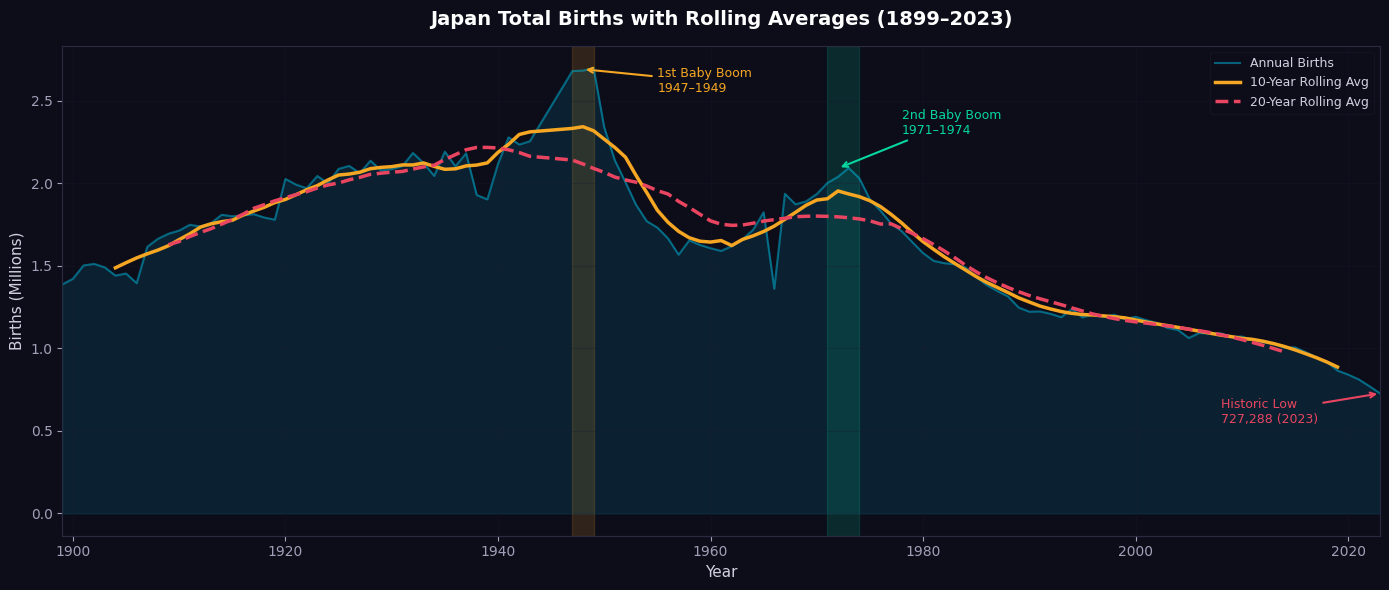

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

# Fill + raw line
ax.fill_between(df['year'], df['total_births'] / 1e6,
                alpha=0.12, color=C['teal'])
ax.plot(df['year'], df['total_births'] / 1e6,
        color=C['teal'], linewidth=1.5,
        alpha=0.5, label='Annual Births')

# Rolling averages
ax.plot(df['year'], df['rolling_10'] / 1e6,
        color=C['gold'], linewidth=2.5,
        label='10-Year Rolling Avg')
ax.plot(df['year'], df['rolling_20'] / 1e6,
        color=C['red'], linewidth=2.5,
        linestyle='--', label='20-Year Rolling Avg')

# Baby boom highlights
ax.axvspan(1947, 1949, alpha=0.15, color=C['gold'])
ax.axvspan(1971, 1974, alpha=0.15, color=C['green'])

# Annotations
ax.annotate('1st Baby Boom\n1947–1949',
            xy=(1948, 2.69),
            xytext=(1955, 2.55),
            arrowprops=dict(arrowstyle='->', color=C['gold'], lw=1.5),
            color=C['gold'], fontsize=9)

ax.annotate('2nd Baby Boom\n1971–1974',
            xy=(1972, 2.09),
            xytext=(1978, 2.3),
            arrowprops=dict(arrowstyle='->', color=C['green'], lw=1.5),
            color=C['green'], fontsize=9)

ax.annotate('Historic Low\n727,288 (2023)',
            xy=(2023, 0.727),
            xytext=(2008, 0.55),
            arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5),
            color=C['red'], fontsize=9)

ax.set_title("Japan Total Births with Rolling Averages (1899–2023)",
             fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Births (Millions)")
ax.set_xlim(1899, 2023)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/final_01_total_births.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

> Japan's births peaked at **2.69M in 1949** then declined to
> **727K in 2023**. The rolling averages reveal two baby booms
> and a long unbroken structural decline from the 1970s onward.

# Male VS Female Birth 

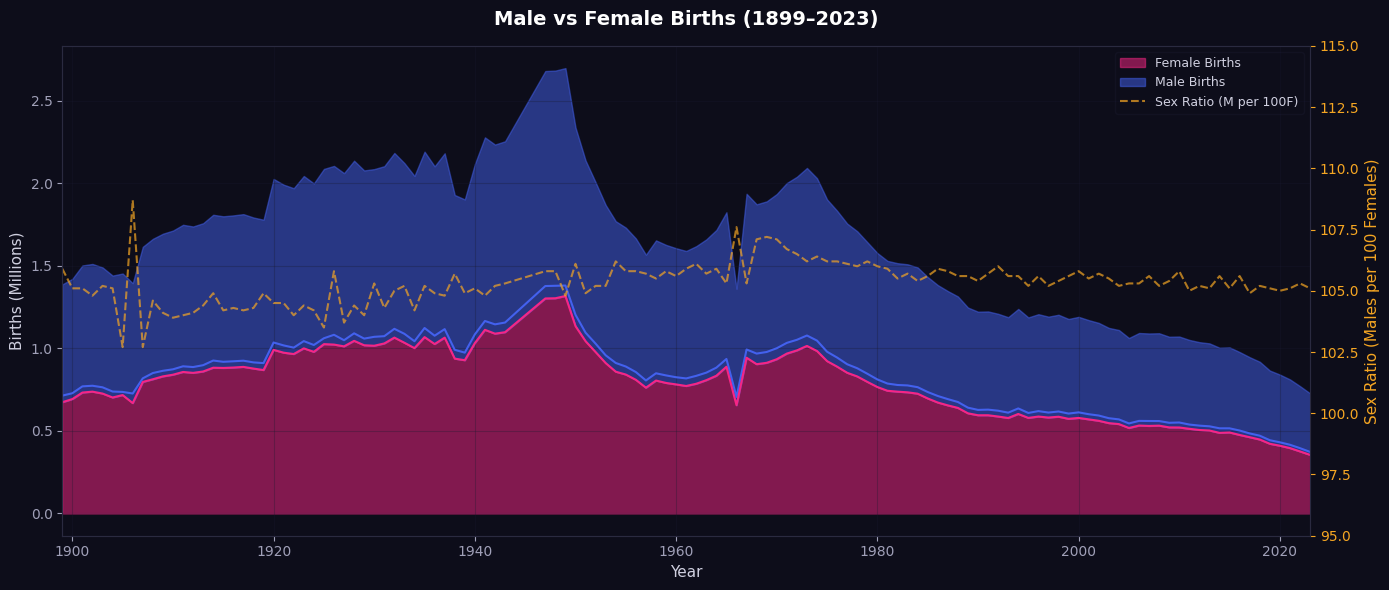

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

# Stacked area
ax.fill_between(df['year'], df['female_births'] / 1e6,
                    alpha=0.5, color=C['pink'], label='Female Births') #alpha = 0.5 → transparency (50%) , 
ax.fill_between(df['year'], df['female_births'] / 1e6,                  #/ 1e6 → converts numbers into millions
                    df['total_births'] / 1e6,
                    alpha=0.5, color=C['blue'], label='Male Births')

# Lines on top
ax.plot(df['year'], df['male_births'] / 1e6,
          color=C['blue'], linewidth=1.5)
ax.plot(df['year'], df['female_births'] / 1e6,
          color=C['pink'], linewidth=1.5)

# Sex ratio second axis
ax2 = ax.twinx() #ax = original axis (used for births data) / twinx() creates a new axis sharing the same X-axis
ax2.set_facecolor('#0d0d1a')
ax2.plot(df['year'], df['sex_ratio_at_birth'],
          color=C['gold'], linewidth=1.5,
          linestyle='--', alpha=0.7,
          label='Sex Ratio (M per 100F)')
ax2.set_ylabel("Sex Ratio (Males per 100 Females)", color=C['gold'])
ax2.tick_params(axis='y', colors=C['gold'])
ax2.set_ylim(95, 115)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax.set_title("Male vs Female Births (1899–2023)",
               fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Births (Millions)")
ax.set_xlim(1899, 2023)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/final_02_male_female.png', dpi=150,
               bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

>  Male births consistently outnumber female births across all 124 years.

> The sex ratio has stayed remarkably stable at **~105 males per 100 females**

> — only the total volume is collapsing, not the biological balance.

# Crude Birth Rate Vs Total Fertitliy Rate 

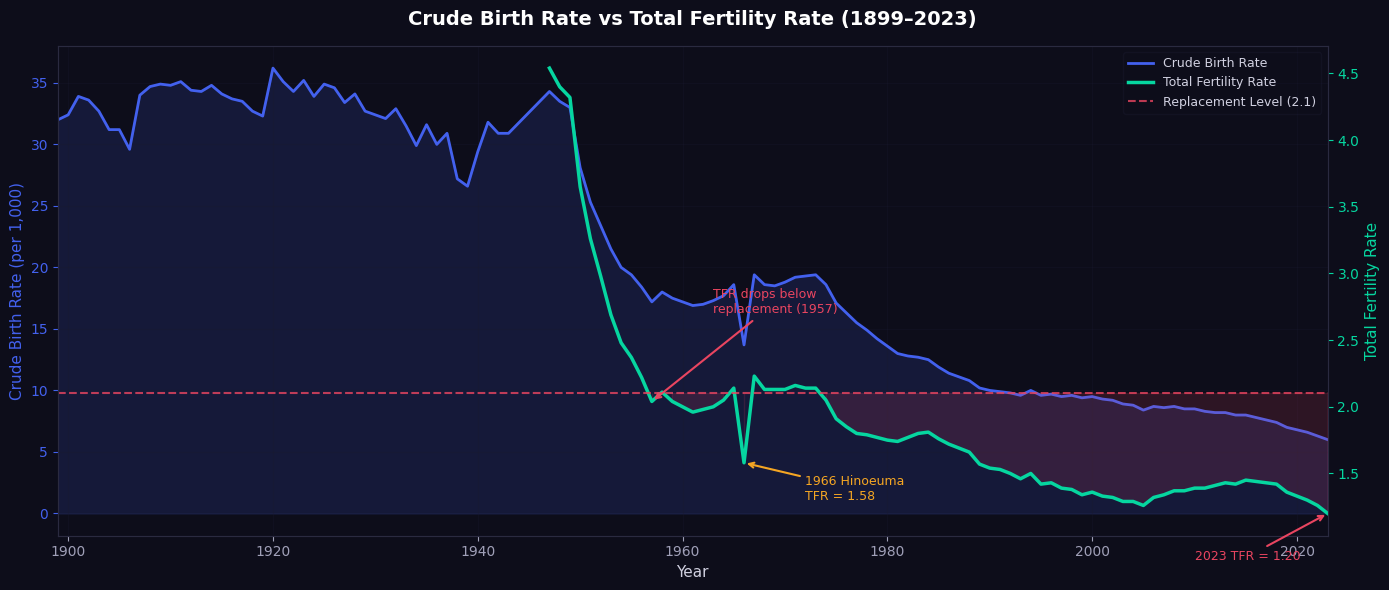

In [8]:
tfr = df.dropna(subset=['total_fertility_rate'])

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax2.set_facecolor('#0d0d1a')

# Crude Birth Rate — left axis
ax1.fill_between(df['year'], df['crude_birth_rate'],
                    alpha=0.15, color=C['blue'])
ax1.plot(df['year'], df['crude_birth_rate'],
          color=C['blue'], linewidth=2,
          label='Crude Birth Rate')

# TFR — right axis
ax2.plot(tfr['year'], tfr['total_fertility_rate'],
          color=C['green'], linewidth=2.5,
          label='Total Fertility Rate')
ax2.axhline(y=2.1, color=C['red'], linewidth=1.5,
               linestyle='--', alpha=0.8,
               label='Replacement Level (2.1)')
ax2.fill_between(tfr['year'], tfr['total_fertility_rate'], 2.1,
                    where=(tfr['total_fertility_rate'] < 2.1),
                    alpha=0.15, color=C['red'])

# Annotations
ax2.annotate('TFR drops below\nreplacement (1957)',
               xy=(1957, 2.04),
               xytext=(1963, 2.7),
               arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5),
               color=C['red'], fontsize=9)

ax2.annotate('1966 Hinoeuma\nTFR = 1.58',
               xy=(1966, 1.58),
               xytext=(1972, 1.3),
               arrowprops=dict(arrowstyle='->', color=C['gold'], lw=1.5),
               color=C['gold'], fontsize=9)

ax2.annotate('2023 TFR = 1.20',
               xy=(2023, 1.20),
               xytext=(2010, 0.85),
               arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5),
               color=C['red'], fontsize=9)

# Axis labels & colours
ax1.set_ylabel("Crude Birth Rate (per 1,000)", color=C['blue'])
ax1.tick_params(axis='y', colors=C['blue'])
ax2.set_ylabel("Total Fertility Rate", color=C['green'])
ax2.tick_params(axis='y', colors=C['green'])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title("Crude Birth Rate vs Total Fertility Rate (1899–2023)",
               fontweight='bold', pad=15)
ax1.set_xlabel("Year")
ax1.set_xlim(1899, 2023)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/final_03_cbr_vs_tfr.png', dpi=150,
               bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

> 📌 Both indicators tell the same story — steady decline since the 1920s.

> TFR crossed the replacement level of **2.1 in 1957** and never recovered.

> The red shaded area shows **66 consecutive years** below replacement level.

> By 2023 TFR hit **1.20** — nearly half of what is needed to sustain population.